# Création des Datasets pour LSTM (ISMN + ERA5)

Ce notebook est le point de passage final pour extraire les séries ISMN, filtrer et gérer les NaN, télécharger les données météorologiques locales via ERA5-Land (Earth Engine), aligner le tout et sauvegarder les séquences complètes sous forme de `.csv` prêts pour l'entraînement de notre LSTM.

In [2]:
%pip install ismn
%pip install pytesmo


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import matplotlib.pyplot as plt
import random
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from random import shuffle
from pytesmo.time_series.anomaly import calc_anomaly
from ismn.interface import ISMN_Interface

from Fcn_for_csv import (
    resample_timeseries,
    interpolate_timeseries,
    cut_timeseries,
    filter_outliers,
    find_abnormal_sequences,
    save_to_csv,
    get_meteo_data,
    detect_time_frequency,
    read_and_clean_data,
    create_clusters_dict,
    filter_data
    )

# Exemples de courbes entières

In [4]:
ismn_raw_path = "/home/theodore/Documents/Get_Datasets/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520"
ismn_data = ISMN_Interface(ismn_raw_path, parallel=True)

Using the existing ismn metadata in /home/theodore/Documents/Get_Datasets/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520/python_metadata/Data_separate_files_header_20160101_20260520_13465_BBMF_20260520.csv to set up ISMN_Interface. 
If there are issues with the data reader, you can remove the metadata csv file to repeat metadata collection.


In [5]:
sensor_list = filter_data(ismn_data=ismn_data, 
                          var = 'soil_moisture', 
                          Climate = ['Cfb'], 
                          land_cover = [10], 
                          frequency = 'H', 
                          depth_from = 0., 
                          depth_to = 0.15)

In [7]:
meta = sensor_list[0].metadata.to_pd()
print(meta)

variable        key       
clay_fraction   val                          22.0
                depth_from                    0.0
                depth_to                      0.3
climate_KG      val                           Cfb
climate_insitu  val                       unknown
elevation       val                          39.0
instrument      val               Acclima-TDT_1_2
                depth_from                    0.1
                depth_to                      0.1
latitude        val                      52.86073
lc_2000         val                            10
lc_2005         val                            10
lc_2010         val                            10
longitude       val                      -1.12685
network         val                     COSMOS-UK
organic_carbon  val                          0.74
                depth_from                    0.0
                depth_to                      0.3
sand_fraction   val                          41.0
                depth_f

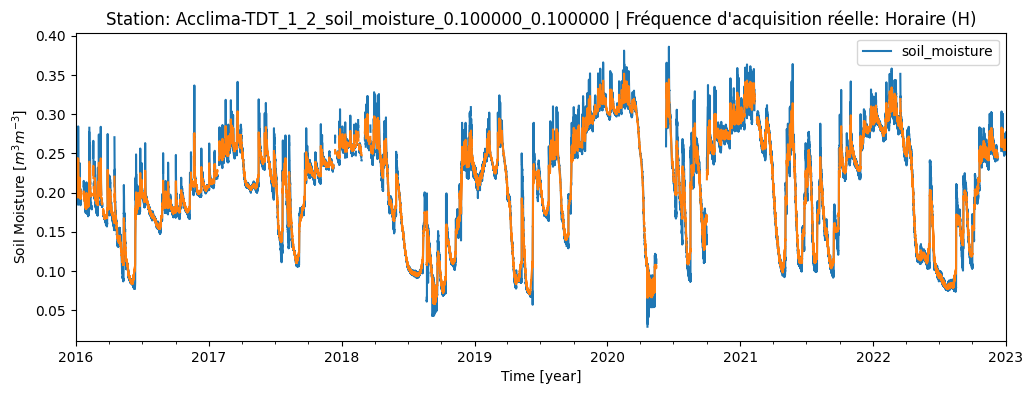

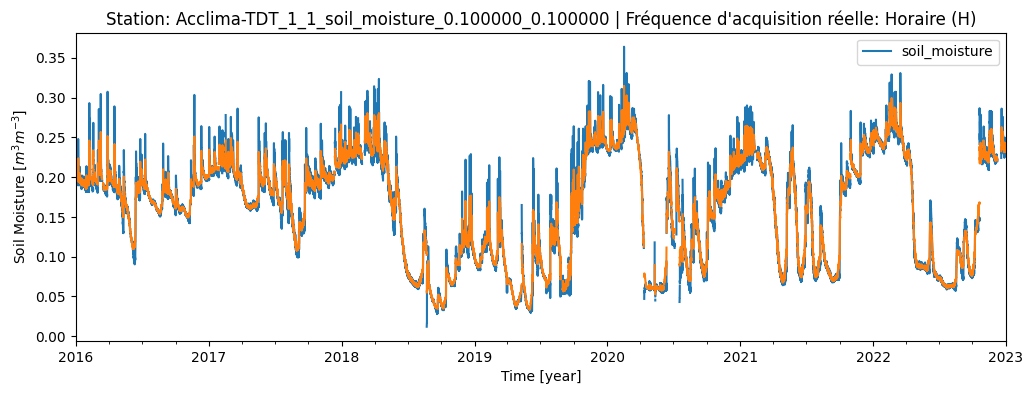

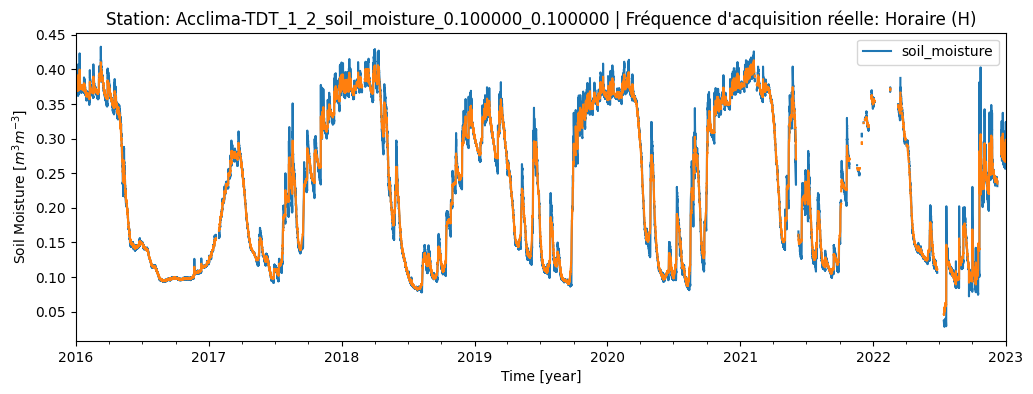

In [ ]:
# Visualisation des séries temporelles de l'humidité du sol pour les stations avec :
# le label cropland (LC_2000 = 10) 
# et Climate_KG = 'Cfb'
compteur = 0

for sensor in sensor_list:

    data = read_and_clean_data(sensor)
    
    anomaly = data['soil_moisture'] - 0.5*calc_anomaly(data['soil_moisture'], window_size=15)
    freq = detect_time_frequency(data)

    if freq == 'H':
        compteur += 1
        plot_title = f"Station: {sensor} | Fréquence d'acquisition réelle: Horaire (H)"
        data.plot(y='soil_moisture', title=plot_title, figsize=(12, 4))
        anomaly.plot(y='soil_moisture', title=plot_title, figsize=(12, 4))
        plt.xlabel("Time [year]")
        plt.ylabel("Soil Moisture [$m^3 m^{-3}$]") 
        if compteur >= 3:
            break
    else :
        continue

In [6]:
clusters_dict, sensor_list, df_features = create_clusters_dict(sensor_list, method='soil_type', verbose=True)
n_clusters = len(clusters_dict)

Station: Acclima-TDT_1_2_soil_moisture_0.050000_0.050000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_1_soil_moisture_0.050000_0.050000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_1_soil_moisture_0.150000_0.150000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_2_soil_moisture_0.150000_0.150000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_2_soil_moisture_0.100000_0.100000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: Acclima-TDT_1_1_soil_moisture_0.100000_0.100000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: DeltaT-ThetaProbe-ML3_1_1_soil_moisture_0.050000_0.050000 | Propriétés du sol manquantes. Valeurs utilisées : Clay=nan, Silt=nan, Sand=nan
Station: DeltaT-ThetaPro

In [7]:
from pytesmo.temporal_matching import temporal_collocation

# matched = temporal_collocation(df_ismn, df_satellite_or_local.set_index('DateTime'), window=1)    

In [ ]:
# ---------- CONFIGURATION ---------- #

BASE_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/csv_for_hrsm"
MIN_LENGTH = 100  # Seuil de jours minimum continus sans NaN

compteur_fichiers = 0

for sensor in sensor_list:

    df_full = read_and_clean_data(sensor)
    df_daily_mean = resample_timeseries(df_full, freq='D', method='mean', start_date='2016-01-01', end_date='2026-12-31')

    if df_daily_mean is None or df_daily_mean.empty:
        print(f"[{sensor}] Série temporelle vide après resampling. Skip.")
        continue

    df_interp = interpolate_timeseries(df_daily_mean)
    sequences = cut_timeseries(df_interp, min_length=MIN_LENGTH)

    if not sequences:
        print(f"[{sensor}] Aucune séquence continue de longueur >= {MIN_LENGTH} jours. Skip.")
        continue

    # 2. Récupération sécurisée des métadonnées ISMN
    meta = sensor.metadata.to_pd()
    
    # Fonction pour sécuriser l'extraction et éviter les requêtes de .val sur des objets nuls
    def get_meta(key, default=np.nan):
        return meta.get(key, default).val if key in meta else default

    lat = get_meta('latitude')
    lon = get_meta('longitude')
    elevation = get_meta('elevation')
    clay = get_meta('clay_fraction')
    silt = get_meta('silt_fraction')
    sand = get_meta('sand_fraction')
    saturation = get_meta('saturation')
    
    # La profondeur se récupère dans la variable spécifique
    
    depth_from = meta['variable'].depth_from
    depth_to = meta['variable'].depth_to

    if pd.isna(lat) or pd.isna(lon):
        print(f"[{sensor}] Latitude/Longitude manquantes. Skip.")
        continue

    # == OPTIMISATION: Télécharger ERA5 en une seule fois pour toute la plage dispo ! ==
    overall_start = sequences[0].index.min().strftime('%Y-%m-%d')
    overall_end = sequences[-1].index.max().strftime('%Y-%m-%d')
    
    df_era5_full = get_meteo_data(lat, lon, overall_start, overall_end)
    
    if not df_era5_full.empty:
        df_era5_full.index = pd.to_datetime(df_era5_full.index)
        # Profil vent logarithmique FAO (10m -> 2m standard agro)
        if 'WIND' in df_era5_full.columns:
            df_era5_full['WIND'] = df_era5_full['WIND'] * 0.748

    final_sequences = []
    
    # 3. Alignement avec la Météo ERA5 pour chaque séquence continue
    for seq in sequences:
        if df_era5_full.empty:
            continue
            
        # Fusion (Inner Join garantit qu'on garde que les jours valides des 2 côtés)
        df_merged = seq.join(df_era5_full, how='inner')
        
        if not df_merged.empty and len(df_merged) >= MIN_LENGTH:
            # Ajout de toutes les métadonnées statiques en colonnes
            df_merged['Latitude'] = lat
            df_merged['Longitude'] = lon
            df_merged['Elevation'] = elevation
            df_merged['Depth_from'] = depth_from
            df_merged['Depth_to'] = depth_to
            df_merged['Clay_fraction'] = clay
            df_merged['Silt_fraction'] = silt
            df_merged['Sand_fraction'] = sand
            df_merged['Saturation'] = saturation
            
            final_sequences.append(df_merged)

    # 4. Sauvegarde dans des sous-dossiers selon la profondeur
    if not pd.isna(depth_to) and final_sequences:
        
        # Factorisation du processus de nommage des dossiers
        depth_thresholds = [0.15, 0.25, 0.35, 0.45, 0.55, 0.65]
        folder_depth = "depth_0.7_plus"
        
        for t in depth_thresholds:
            if depth_to <= t:
                folder_depth = f"depth_{t - 0.05:.1f}"  # ex: 0.15-0.05 -> depth_0.1
                break
                
        dossier_destination = os.path.join(BASE_DEST_DIR, folder_depth, str(sensor))
        
        save_to_csv(final_sequences, dossier_destination)
        print(f"[{compteur_fichiers+1}/{len(sensor_list)}] {sensor} => {len(final_sequences)} séquence(s) sauvegardées.")
        compteur_fichiers += 1

print(f"\n---\nTerminé ! {compteur_fichiers} sites traités avec succès et enregistrés dans le dataset final.")

5 séquences enregistrées sous : /home/theodore/Documents/Get_Datasets/csv_for_hrsm/depth_0.1/Acclima-TDT_1_2_soil_moisture_0.100000_0.100000_X.csv
[1/153] Acclima-TDT_1_2_soil_moisture_0.100000_0.100000 => 5 séquence(s) sauvegardées.
5 séquences enregistrées sous : /home/theodore/Documents/Get_Datasets/csv_for_hrsm/depth_0.1/Acclima-TDT_1_1_soil_moisture_0.100000_0.100000_X.csv
[2/153] Acclima-TDT_1_1_soil_moisture_0.100000_0.100000 => 5 séquence(s) sauvegardées.
7 séquences enregistrées sous : /home/theodore/Documents/Get_Datasets/csv_for_hrsm/depth_0.1/Acclima-TDT_1_2_soil_moisture_0.100000_0.100000_X.csv
[3/153] Acclima-TDT_1_2_soil_moisture_0.100000_0.100000 => 7 séquence(s) sauvegardées.
7 séquences enregistrées sous : /home/theodore/Documents/Get_Datasets/csv_for_hrsm/depth_0.1/Acclima-TDT_1_1_soil_moisture_0.100000_0.100000_X.csv
[4/153] Acclima-TDT_1_1_soil_moisture_0.100000_0.100000 => 7 séquence(s) sauvegardées.
5 séquences enregistrées sous : /home/theodore/Documents/Get_Dat

In [ ]:
import sys
import os
import glob
import pandas as pd
from Fcn_for_csv import get_site_soil_properties_as_dataframe

BASE_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/csv_for_hrsm"

# Recherche des fichiers CSV générés précédemment
csv_files = glob.glob(os.path.join(BASE_DEST_DIR, "*", "*.csv"))

soil_properties_cache = {}
all_results = []
compteur_fichiers = 0

if csv_files:
    print(f"{len(csv_files)} fichiers CSV trouvés. Début de l'extraction des propriétés du sol...\n")
    
    for csv_file in csv_files:
        try:
            df_test = pd.read_csv(csv_file, nrows=1) # On ne lit que la première ligne pour être plus rapide
            
            # Extraction des coordonnées
            lat = df_test['Latitude'].iloc[0]
            lon = df_test['Longitude'].iloc[0]
            
            site_id = os.path.basename(csv_file).split('_')[0]
            
            # Arrondir pour gérer les imprécisions des flottants
            coords_key = (round(lon, 4), round(lat, 4))
            
            if coords_key in soil_properties_cache:
                print(f"[{site_id}] Coordonnées {coords_key} connues -> Récupération depuis le cache.")
                df_props = soil_properties_cache[coords_key].copy()
                df_props['site_id'] = site_id
            else:
                print(f"[{site_id}] Nouvelles coordonnées {coords_key} -> Téléchargement & calcul...")
                df_props = get_site_soil_properties_as_dataframe(
                    site_id=site_id,
                    longitude=lon,
                    latitude=lat,
                    soil_types=["bulk","silt","clay","sand","Ksat","dem"],
                    verbose=False # Désactivé pour ne pas polluer l'écran lors du parcours de la boucle
                )
                soil_properties_cache[coords_key] = df_props
            
            all_results.append(df_props)
            display(df_props.head())
            
            print(f"[{compteur_fichiers+1}/{len(csv_files)}] {site_id}  ")
            compteur_fichiers += 1

        except Exception as e:
            print(f"⚠️ Erreur lors du traitement du fichier {csv_file} : {e}")

    # Assemblage de tous les résultats dans un DataFrame final unique et export
    if all_results:
        df_all_sites_soil = pd.concat(all_results, ignore_index=True)
        # Supprimer les potentiels doublons parfaits (si le même site_id apparaît plusieurs fois avec les mêmes params)
        df_all_sites_soil = df_all_sites_soil.drop_duplicates()
        
        display(df_all_sites_soil.head())
        
        # Sauvegarde d'un fichier maître des propriétés du sol
        master_output = os.path.join(BASE_DEST_DIR, "ISMN_Soil_Properties_Master.csv")
        df_all_sites_soil.to_csv(master_output, index=False)
        print(f"\nExtraction terminée ! Fichier maître sauvegardé ici : {master_output}")
else:
    print("Aucun fichier CSV n'a été trouvé. Exécutez d'abord la cellule précédente.")

145 fichiers CSV trouvés. Début de l'extraction des propriétés du sol...

[Acclima-TDT] Nouvelles coordonnées (np.float64(-0.0444), np.float64(52.1322)) -> Téléchargement & calcul...


In [ ]:
import os
import pandas as pd
import numpy as np
import ee
import requests
import tempfile
import rasterio
from Fcn_for_csv import compute_and_save_terrain_attributes

# Initialisation de GEE
try:
    ee.Initialize()
except Exception as e:
    print("Authentification à Google Earth Engine...")
    ee.Authenticate()
    ee.Initialize()

print("--- EXÉCUTION DU PATCH DEM AVEC GEE (JAXA ALOS) + WHITEBOX TOOLS ---")
df_all_sites_soil = pd.read_csv("/home/theodore/Documents/Get_Datasets/csv_for_hrsm/ISMN_Soil_Properties_Master.csv")
df_missing_topo = df_all_sites_soil[df_all_sites_soil['dem_twi'].isna() | df_all_sites_soil['dem_slope'].isna() | df_all_sites_soil['dem_aspect'].isna()]

# Identifier les sites manquants uniques
missing_coords = df_missing_topo[['latitude', 'longitude']].drop_duplicates()

# Charger le DEM de la JAXA via GEE
dem = ee.ImageCollection("JAXA/ALOS/AW3D30/V4_1").select('DSM').mosaic()

# On stocke les résultats
dem_patch_results = {}

for _, row in missing_coords.iterrows():
    lat = row['latitude']
    lon = row['longitude']
    
    print(f"\nCorrection pour (lat={lat}, lon={lon})...")
    try:
        # Créer une bounding box autour du point pour l'analyse topographique
        buffer_deg = 0.02
        bbox = ee.Geometry.Rectangle([lon - buffer_deg, lat - buffer_deg, lon + buffer_deg, lat + buffer_deg])
        
        # Récupérer l'URL de téléchargement direct du GeoTIFF
        url = dem.getDownloadURL({
            'scale': 30,
            'crs': 'EPSG:4326',
            'region': bbox,
            'format': 'GEO_TIFF'
        })
        
        # Télécharger et traiter en local
        response = requests.get(url)
        with tempfile.TemporaryDirectory() as tmp_dir:
            raw_dem_path = os.path.join(tmp_dir, "raw_dem.tif")
            dem_path = os.path.join(tmp_dir, "dem.tif")
            with open(raw_dem_path, "wb") as f:
                f.write(response.content)
            
            # WhiteboxTools est très stricte sur le format des fichiers. 
            # Les TIF de GEE contiennent souvent des métadonnées ou compressions qu'il n'aime pas.
            # On ré-écrit le TIF proprement via rasterio avant de lui passer.
            with rasterio.open(raw_dem_path) as src:
                data = src.read(1)
                profile = src.profile.copy()
                data = data.astype('float32') # Float32 est plus standard pour algorithmes topographiques
                profile.update(dtype='float32', compress='lzw', nodata=-9999.0)
            
            with rasterio.open(dem_path, 'w', **profile) as dst:
                dst.write(data, 1)
            
            topo_data = {}
            # Lire l'élévation au centre
            with rasterio.open(dem_path) as src:
                val = next(src.sample([(lon, lat)]))[0]
                topo_data['dem_m_30m_depth'] = val
                
            # Calculer slope, aspect, TWI avec WhiteboxTools
            output_records = compute_and_save_terrain_attributes(dem_path, verbose=True)
            
            for rec in output_records:
                attr_name = rec["output_stem"].split('_')[-1] # slope, aspect ou twi
                with rasterio.open(rec['local_path']) as src:
                    val = next(src.sample([(lon, lat)]))[0]
                    topo_data[f'dem_{attr_name}'] = val
            
        print(f"✅ Attributs extraits: {topo_data}")
        dem_patch_results[(lat, lon)] = topo_data
        
    except Exception as e:
        print(f"❌ Erreur pour ({lat}, {lon}): {e}")

# Mise à jour de df_all_sites_soil
for index, row in df_all_sites_soil.iterrows():
    lat = row['latitude']
    lon = row['longitude'] 
    
    # Si on a un résultat calculé
    if tuple([lat, lon]) in dem_patch_results:
        res = dem_patch_results[(lat, lon)]
        print(f"\nMise à jour pour index {index} (lat={lat}, lon={lon})...")
        if res:
            df_all_sites_soil.at[index, 'dem_m_30m_depth'] = res.get('dem_m_30m_depth', np.nan)
            df_all_sites_soil.at[index, 'dem_slope'] = res.get('dem_slope', np.nan)
            df_all_sites_soil.at[index, 'dem_aspect'] = res.get('dem_aspect', np.nan)
            df_all_sites_soil.at[index, 'dem_twi'] = res.get('dem_twi', np.nan)

print("\n--- PATCH TERMINE ---")
print("Vérification des lignes restantes avec des NaN (devrait être vide si tout a réussi) :")
print(df_all_sites_soil[df_all_sites_soil['dem_twi'].isna()])

# Sauvegarder à nouveau le master csv pour valider le correctif
export_path = '/home/theodore/Documents/Get_Datasets/csv_for_hrsm/ISMN_Soil_Properties_Master.csv'
df_all_sites_soil.to_csv(export_path, index=False)
print(f"Sauvegardé avec correctifs dans {export_path}")

--- EXÉCUTION DU PATCH DEM AVEC GEE (JAXA ALOS) + WHITEBOX TOOLS ---

Correction pour (lat=-34.72125, lon=173.04782)...
    Calcul des attributs de terrain pour dem.tif...
      ✓ SLOPE: /tmp/tmp6mtarf1s/dem_slope.tif (0.09 MB)
      ✓ ASPECT: /tmp/tmp6mtarf1s/dem_aspect.tif (0.09 MB)
      ✓ TWI: /tmp/tmp6mtarf1s/dem_twi.tif (0.09 MB)
✅ Attributs extraits: {'dem_m_30m_depth': np.float32(46.0), 'dem': np.float32(46.0), 'dem_slope': np.float32(2.514076), 'dem_aspect': np.float32(332.4617), 'dem_twi': np.float32(-3.1473725)}

Correction pour (lat=-36.70378, lon=174.55472)...
    Calcul des attributs de terrain pour dem.tif...
      ✓ SLOPE: /tmp/tmpsrbyvwls/dem_slope.tif (0.09 MB)
      ✓ ASPECT: /tmp/tmpsrbyvwls/dem_aspect.tif (0.09 MB)
      ✓ TWI: /tmp/tmpsrbyvwls/dem_twi.tif (0.09 MB)
✅ Attributs extraits: {'dem_m_30m_depth': np.float32(47.0), 'dem': np.float32(47.0), 'dem_slope': np.float32(9.49905), 'dem_aspect': np.float32(84.27713), 'dem_twi': np.float32(-6.4311485)}

Correction 

# Prendre les csv et ajouter / Compléter les colonnes 

In [ ]:
import glob
import os
import pandas as pd
import numpy as np
from Fcn_for_csv import update_local_csv_with_master

BASE_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/csv_for_hrsm"
OUTPUT_DEST_DIR = r"/home/theodore/Documents/Get_Datasets/csv_for_hrsm/csv_meteo_and_soil"
master_path = os.path.join(BASE_DEST_DIR, "ISMN_Soil_Properties_Master.csv")




df_master = pd.read_csv(master_path)
csv_files = glob.glob(os.path.join(BASE_DEST_DIR, "*", "*.csv"))


print(f"{len(csv_files)} fichiers CSV de séries temporelles trouvés. Début du test...\n")

# Depth < 30cm -> On prend les propriétés du sol à 30cm de profondeur (car c'est la plus proche de la réalité du capteur)
colonnes=["dem_m_30m_depth", "bulk_m_30m_0cm_30cm", "sand_m_30m_0cm_30cm", "silt_m_30m_0cm_30cm", 
          "clay_m_30m_0cm_30cm", "ksat_m_1km_0cm", "dem_slope", "dem_aspect", "dem_twi"]

csv_folder = os.path.join(OUTPUT_DEST_DIR, "depth_0.1")
os.makedirs(csv_folder, exist_ok=True)
for csv_file in csv_files:
    
    df = update_local_csv_with_master(csv_file, df_master, cols=colonnes, verbose=False)

    new_csv_path = os.path.join(csv_folder, os.path.basename(csv_file))
    df.to_csv(new_csv_path, index=False)
    print(f"✅ {os.path.basename(csv_file)} -> {os.path.basename(new_csv_path)} (colonnes mises à jour : {', '.join(colonnes)})")

145 fichiers CSV de séries temporelles trouvés. Début du test...

✅ Acclima-TDT_1_1_soil_moisture_0.150000_0.150000_3.csv -> Acclima-TDT_1_1_soil_moisture_0.150000_0.150000_3.csv (colonnes mises à jour : dem_m_30m_depth, bulk_m_30m_0cm_30cm, sand_m_30m_0cm_30cm, silt_m_30m_0cm_30cm, clay_m_30m_0cm_30cm, ksat_m_1km_0cm, dem_slope, dem_aspect, dem_twi)
✅ Acclima-TDT_1_1_soil_moisture_0.100000_0.100000_3.csv -> Acclima-TDT_1_1_soil_moisture_0.100000_0.100000_3.csv (colonnes mises à jour : dem_m_30m_depth, bulk_m_30m_0cm_30cm, sand_m_30m_0cm_30cm, silt_m_30m_0cm_30cm, clay_m_30m_0cm_30cm, ksat_m_1km_0cm, dem_slope, dem_aspect, dem_twi)
✅ DeltaT-ThetaProbe-ML3_1_1_soil_moisture_0.100000_0.100000_6.csv -> DeltaT-ThetaProbe-ML3_1_1_soil_moisture_0.100000_0.100000_6.csv (colonnes mises à jour : dem_m_30m_depth, bulk_m_30m_0cm_30cm, sand_m_30m_0cm_30cm, silt_m_30m_0cm_30cm, clay_m_30m_0cm_30cm, ksat_m_1km_0cm, dem_slope, dem_aspect, dem_twi)
✅ DeltaT-ThetaProbe-ML2x_2_1_soil_moisture_0.100000_0

In [ ]:
# @title HLSL30

###note: no scale factor for HLSL30 product.

def bitwiseExtract(img, fromBit, toBit):
  maskSize = ee.Number(1).add(toBit).subtract(fromBit)
  mask = ee.Number(1).leftShift(maskSize).subtract(1)
  return img.rightShift(fromBit).bitwiseAnd(mask)

# remove low quality data
def maskHLSL30(image):
  qcDay = image.select('Fmask')
  cloud = bitwiseExtract(qcDay, 1, 1).eq(0)
  cloudshadow = bitwiseExtract(qcDay, 3, 3).eq(0)
  snowice = bitwiseExtract(qcDay, 4, 4).eq(0)
  water = bitwiseExtract(qcDay, 5, 5).eq(0)
  aerosol = bitwiseExtract(qcDay, 6, 7).lte(2)
  mask = cloud.And(cloudshadow).And(snowice).And(water).And(aerosol)

  return    image.updateMask(mask).copyProperties(image, ['system:time_start'])


HLSL30 = ee.ImageCollection("NASA/HLS/HLSL30/v002").filterBounds(roi)\
    .filterDate(start_date, end_date).map(maskHLSL30) \
		.select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B9', 'B10', 'B11'])


In [ ]:
# @title Sentinel-2
# Sentinel-2 images


# old version
# def maskSentinel2(img):
#   cloudOpaqueBitMask = (1 << 10);
#   cloudCirrusMask = (1 << 11);
#   # Get the pixel QA band.
#   qa = img.select('QA60')
#   # Both flags should be set to zero, indicating clear conditions.
#   mask = qa.bitwiseAnd(cloudOpaqueBitMask).eq(0) \
#                 .And(qa.bitwiseAnd(cloudCirrusMask).eq(0))
#   return img.updateMask(mask).copyProperties(img, ['system:time_start'])                  #.multiply(0.0001).toFloat().copyProperties(img, ['mydate'])  # after applying updateMask(). all properties will be lost


def maskSentinel2(img):
  # Get the pixel QA band.
  scl = img.select('SCL')
  mask = scl.neq(8).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
  return img.updateMask(mask).copyProperties(img, ['system:time_start'])

# def add_date(img):
#   date_start = ee.Date(img.get('system:time_start')).format('YYYY-MM-dd-HH')
#   return img.set('mydate', date_start)


Sentinel2 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")\
            .filterDate(start_date, end_date).filterBounds(roi)\
            .map(maskSentinel2)\
            .select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12'])


In [ ]:
# @title Sentinel-1

def preprocess_vv(image):
    vv_masked = image.updateMask(image.gt(-20).And(image.lt(-5)))
    vv_filtered = vv_masked.convolve(ee.Kernel.gaussian(3))
    return vv_filtered #.rename('VV').copyProperties(image, ['system:time_start'])

# Define preprocessing for VH
def preprocess_vh(image):
    vh_masked = image.updateMask(image.gt(-30).And(image.lt(-10)))
    vh_filtered = vh_masked.convolve(ee.Kernel.gaussian(3))
    return vh_filtered #.rename('VH').copyProperties(image, ['system:time_start'])


def merge_bands(image):
    vv = image.select('VV')
    vh = image.select('VH')
    angle = image.select('angle')

    vv_prep = preprocess_vv(vv)      # Apply mask + smoothing to VV
    vh_prep = preprocess_vh(vh)      # Apply mask + smoothing to VH

    merged = vv_prep.addBands(vh_prep).addBands(angle.rename('angle'))

    return merged.copyProperties(image, ['system:time_start'])

def to_float(image):
    all_bands = image.bandNames()
    return image.select(all_bands).float().copyProperties(image, ['system:time_start'])

Sentinel1 = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterDate(start_date, end_date)
    .filterBounds(roi)
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
    # .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))
    .sort('SLC_Processing_start')
    .map(merge_bands).map(to_float)
)



In [ ]:
# @title parallel processing  for HLSL30
import concurrent.futures


def process_day(idx, feature_collection_crop):
  print(f'is running the {idx}th group')
  tfirst = tfirsts[idx]
  tlast = tlasts[idx]

  HLSL30_sub = HLSL30.filterDate(tfirst, tlast)
  Sentinel2_sub = Sentinel2.filterDate(tfirst, tlast)
  sentinel1_sub = Sentinel1.filterDate(tfirst, tlast)

  def sample_with_time(image):
        samples = image.sampleRegions(
            collection=feature_collection_crop,
            scale=100
        )
        return samples.map(lambda f: f.set('system:time_start', image.get('system:time_start')))

  # sentinel2
  Sentinel2_sampled_points = Sentinel2_sub.map(sample_with_time).flatten()
  points_list = Sentinel2_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('sentinel2: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      Sentinel2_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'B2']
      Sentinel2_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'B3']
      Sentinel2_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'B4']
      Sentinel2_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'B5']
      Sentinel2_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'B6']
      Sentinel2_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'B7']
      Sentinel2_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'B8']
      Sentinel2_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'B8A']
      Sentinel2_arr[8, idx[0], idx[1]] = grouped_df.loc[idx, 'B11']
      Sentinel2_arr[9, idx[0], idx[1]] = grouped_df.loc[idx, 'B12']

  # hlsl30
  HLSL30_sampled_points = HLSL30_sub.map(sample_with_time).flatten()
  points_list = HLSL30_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('hlsl30: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      HLSL30_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'B2']
      HLSL30_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'B3']
      HLSL30_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'B4']
      HLSL30_arr[3, idx[0], idx[1]] = grouped_df.loc[idx, 'B5']
      HLSL30_arr[4, idx[0], idx[1]] = grouped_df.loc[idx, 'B6']
      HLSL30_arr[5, idx[0], idx[1]] = grouped_df.loc[idx, 'B7']
      HLSL30_arr[6, idx[0], idx[1]] = grouped_df.loc[idx, 'B9']
      HLSL30_arr[7, idx[0], idx[1]] = grouped_df.loc[idx, 'B10']
      HLSL30_arr[8, idx[0], idx[1]] = grouped_df.loc[idx, 'B11']

  # sentinel1
  sentinel1_sampled_points = sentinel1_sub.map(sample_with_time).flatten()
  points_list = sentinel1_sampled_points.getInfo()['features']
  data = [point['properties'] for point in points_list]
  df = pd.DataFrame(data)
  # print('sentinel1: ',len(df))
  if 'id_num' in df.columns:
    df['datetime'] = pd.to_datetime(df['system:time_start'], unit='ms')
    df['id_idx'] = [refer_id_idx_dict[id] for id in df['id_num'].tolist()]
    df['time_idx'] = ((df['datetime'] - start_datetime).dt.total_seconds() / 3600).astype(int)
    grouped_df = df.groupby(['time_idx', 'id_idx']).mean()
    indices = grouped_df.index.tolist()
    for idx in indices:
      sentinel1_arr[0, idx[0], idx[1]] = grouped_df.loc[idx, 'VV']
      sentinel1_arr[1, idx[0], idx[1]] = grouped_df.loc[idx, 'VH']
      sentinel1_arr[2, idx[0], idx[1]] = grouped_df.loc[idx, 'angle']


  return idx



if os.path.exists('Sentinel2_arr.npy'):
  Sentinel2_arr = np.load('Sentinel2_arr.npy')
  HLSL30_arr = np.load('HLSL30_arr.npy')
  sentinel1_arr = np.load('sentinel1_arr.npy')
else:
  with concurrent.futures.ThreadPoolExecutor(max_workers=6) as executor:
        results = list(executor.map(lambda idx: process_day(idx, feature_collection), range(len(tfirsts)))) # len(tfirsts)
  print('done')
  np.save('Sentinel2_arr.npy', Sentinel2_arr)
  np.save('HLSL30_arr.npy', HLSL30_arr)
  np.save('sentinel1_arr.npy', sentinel1_arr)

time.sleep(10)
# from google.colab import files
# files.download('Sentinel2_arr.npy')
# files.download('HLSL30_arr.npy')
# files.download('sentinel1_arr.npy')